In [10]:
import pandas as pd
import sqlite3

# Load your sales CSV file
df = pd.read_csv('SQL_Sales_Dataset_200_Rows.xlsx - Sheet1.csv')

# Save it to an SQLite database file
conn = sqlite3.connect('sales.db')
df.to_sql('sales', conn, if_exists='replace', index=False)
conn.close()

print("Created sales.db successfully!")

Created sales.db successfully!


In [2]:
import pandas as pd

df = pd.read_csv("SQL_Sales_Dataset_200_Rows.xlsx - Sheet1.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
   order_id  customer_name  order_date   category sub_category  \
0      1000    Caleb Davis  2025-01-31   Clothing        Jeans   
1      1001  Misty Herrera  2025-05-05   Clothing        Jeans   
2      1002      Rick Soto  2025-06-09   Clothing        Shoes   
3      1003      Sean Haas  2025-02-27  Furniture         Desk   
4      1004       Ann Hall  2025-06-01  Furniture      Cabinet   

     product_name  quantity  unit_price  total_price region  
0       Jeans Try         2        1197         2394   West  
1       Jeans New         9        1509        13581  South  
2        Shoes Us         5        1046         5230   East  
3    Desk Section        10         292         2920  South  
4  Cabinet Center         2         548         1096  North  

Dataset Shape:
(200, 10)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         -

In [3]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Remove duplicate rows
print("\nNumber of duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

# Fill missing numerical values with median
numeric_columns = df.select_dtypes(include="number").columns
df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

# Fill missing categorical values with mode
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nAfter cleaning:")
print("Missing values:")
print(df.isnull().sum())

print("Duplicates:", df.duplicated().sum())

Missing values:
order_id         0
customer_name    0
order_date       0
category         0
sub_category     0
product_name     0
quantity         0
unit_price       0
total_price      0
region           0
dtype: int64

Number of duplicates: 0

After cleaning:
Missing values:
order_id         0
customer_name    0
order_date       0
category         0
sub_category     0
product_name     0
quantity         0
unit_price       0
total_price      0
region           0
dtype: int64
Duplicates: 0


In [4]:
category_revenue = df.groupby("category")["total_price"].sum()

print(category_revenue)

category
Clothing       484259
Electronics    549302
Furniture      714399
Grocery        672147
Name: total_price, dtype: int64


In [5]:
category_revenue = (
    df.groupby("category")["total_price"]
      .sum()
      .sort_values(ascending=False)
)

print(category_revenue)

category
Furniture      714399
Grocery        672147
Electronics    549302
Clothing       484259
Name: total_price, dtype: int64


In [6]:
sorted_data = df.sort_values(
    by=["region", "total_price"],
    ascending=[True, False]
)

print(sorted_data.head(10))

     order_id        customer_name  order_date     category sub_category  \
125      1125        Lynn Garrison  2025-05-14      Grocery       Snacks   
160      1160     Michelle Beltran  2025-03-23    Furniture         Desk   
190      1190    Christopher Meyer  2025-01-18      Grocery         Milk   
167      1167          Julie Adams  2025-03-07      Grocery       Snacks   
115      1115          Gary Osborn  2024-12-24  Electronics       Tablet   
59       1059  Miss Rebecca Levine  2025-02-28     Clothing        Shirt   
157      1157        Patricia Gill  2025-03-23     Clothing       Jacket   
24       1024           Jodi Smith  2025-01-30      Grocery        Bread   
6        1006     Breanna Gonzalez  2025-04-09      Grocery        Bread   
96       1096        Daniel Torres  2025-04-19  Electronics       Tablet   

       product_name  quantity  unit_price  total_price region  
125     Snacks Wish        10        4794        47940   East  
160         Desk Me         9      

In [7]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

print(correlation_matrix)

             order_id  quantity  unit_price  total_price
order_id     1.000000 -0.018182    0.102267     0.099480
quantity    -0.018182  1.000000    0.047996     0.655212
unit_price   0.102267  0.047996    1.000000     0.671318
total_price  0.099480  0.655212    0.671318     1.000000


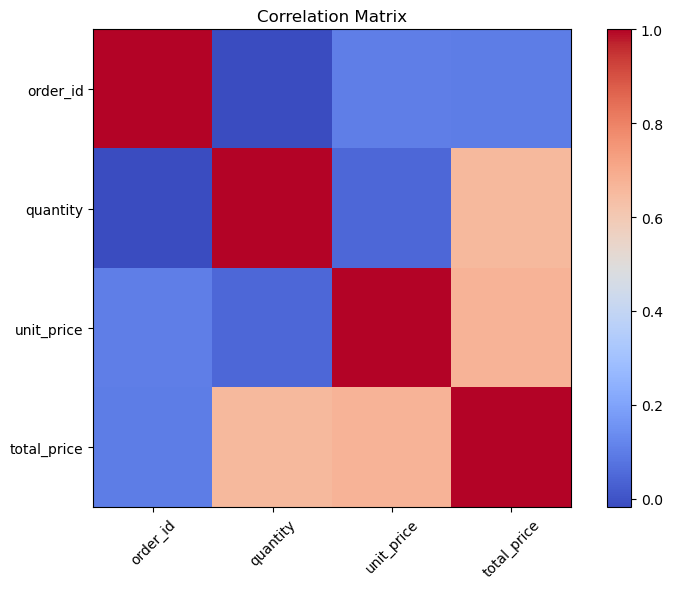

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, cmap="coolwarm")
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()